# **EDA** (Exploratory Data Analysis)

#### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Loading Data

In [2]:
def load_data():
    loaded_data = []

    for i in range(7):
        data = pd.read_excel(f"../data/raw/nez-opendata-202{i}.xlsx")

        data.columns = ['accident_id', 'department', 'municipality', 'date_time', 'longitude', 'latitude', 'accident_type', 'involved_vehicles_num', 'description']
        
        # Date and Time parsing
        data['date_time'] = pd.to_datetime(
            data['date_time'],
            format = "%d.%m.%Y,%H:%M",
            errors = "coerce"
        )

        loaded_data.append(data)
    
    return pd.concat(loaded_data, ignore_index=True)

In [3]:
data = load_data()

#### Base Analysis

In [4]:
data.head()

,accident_id,department,municipality,date_time,longitude,latitude,accident_type,involved_vehicles_num,description
0,1278576,BEOGRAD,BARAJEVO,2020-01-07 10:10:00,20.301589,44.568563,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...
1,1278948,BEOGRAD,BARAJEVO,2020-01-09 12:50:00,20.413280,44.579780,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...
2,1278074,BEOGRAD,BARAJEVO,2020-01-10 10:05:00,20.312560,44.575470,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...
3,1278582,BEOGRAD,BARAJEVO,2020-01-10 15:15:00,20.412190,44.637770,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću različitim p...
4,1278638,BEOGRAD,BARAJEVO,2020-01-16 16:45:00,20.381686,44.633030,Sa povredjenim,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...


In [5]:
data.shape

(205352, 9)

In [6]:
data.dtypes

accident_id                       int64
department                       object
municipality                     object
date_time                datetime64[ns]
longitude                       float64
latitude                        float64
accident_type                    object
involved_vehicles_num            object
description                      object
dtype: object

In [7]:
data.isna().sum()

accident_id              0
department               0
municipality             0
date_time                0
longitude                0
latitude                 0
accident_type            0
involved_vehicles_num    0
description              0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(12)

In [23]:
data[data.duplicated()]

,accident_id,department,municipality,longitude,latitude,accident_type,involved_vehicles_num,description,hour,day_of_week,month,year
3325,1302492,BEOGRAD,OBRENOVAC,20.277090,44.659419,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i životinja,23,6,10,2020
13467,1291853,BEOGRAD,ČUKARICA,20.421833,44.785551,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...,9,5,6,2020
40422,1329694,BEOGRAD,VOŽDOVAC,20.484483,44.783126,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom na kolovozu,1,1,7,2021
60048,1333269,SREMSKA MITROVICA,SREMSKA MITROVICA,19.620961,44.969459,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Ostale nezgode sa najmanje dva vozila – suprot...,13,3,9,2021
81186,1375079,JAGODINA,PARAĆIN,21.618985,43.857867,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i preprekama ...,10,3,6,2022
93994,1392887,SREMSKA MITROVICA,ŠID,19.343341,45.075567,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...,18,5,9,2022
114060,1450561,JAGODINA,PARAĆIN,21.518745,43.860743,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i životinja,16,4,11,2023
169549,1534727,BEOGRAD,RAKOVICA,20.447884,44.744817,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i preprekama ...,13,3,7,2025
182556,1513562,LESKOVAC,LESKOVAC,21.924095,42.996794,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...,10,3,2,2025
200566,1565231,BEOGRAD,ZEMUN,20.304828,44.918957,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i preprekama ...,22,3,2,2026


In [9]:
data.drop_duplicates(inplace=True)

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data = data.drop_duplicates(subset=['accident_id'], keep='first')

In [15]:
data.shape

(203965, 9)

In [28]:
data['department'].unique()

array(['BEOGRAD', 'BOR', 'JAGODINA', 'KIKINDA', 'KRAGUJEVAC', 'KRALJEVO',
       'KRUŠEVAC', 'LESKOVAC', 'NIŠ', 'NOVI PAZAR', 'NOVI SAD', 'PANČEVO',
       'PIROT', 'POŽAREVAC', 'PRIJEPOLJE', 'PROKUPLJE', 'SMEDEREVO',
       'SOMBOR', 'SREMSKA MITROVICA', 'SUBOTICA', 'UŽICE', 'VALJEVO',
       'VRANJE', 'ZAJEČAR', 'ZRENJANIN', 'ČAČAK', 'ŠABAC'], dtype=object)

In [29]:
len(data['department'].unique())

27

In [30]:
data['municipality'].unique()

array(['BARAJEVO', 'GROCKA', 'LAZAREVAC', 'MLADENOVAC', 'NOVI BEOGRAD',
       'OBRENOVAC', 'PALILULA', 'RAKOVICA', 'SAVSKI VENAC', 'SOPOT',
       'STARI GRAD', 'SURČIN', 'VOŽDOVAC', 'VRAČAR', 'ZEMUN', 'ZVEZDARA',
       'ČUKARICA', 'BOR', 'KLADOVO', 'MAJDANPEK', 'NEGOTIN', 'DESPOTOVAC',
       'JAGODINA', 'PARAĆIN', 'REKOVAC', 'SVILAJNAC', 'ĆUPRIJA', 'ADA',
       'KANJIŽA', 'KIKINDA', 'NOVI KNEŽEVAC', 'SENTA', 'ČOKA',
       'ARANĐELOVAC', 'BATOČINA', 'KNIĆ', 'KRAGUJEVAC', 'LAPOVO', 'RAČA',
       'TOPOLA', 'KRALJEVO', 'RAŠKA', 'VRNJAČKA BANJA', 'ALEKSANDROVAC',
       'BRUS', 'KRUŠEVAC', 'TRSTENIK', 'VARVARIN', 'ĆIĆEVAC', 'BOJNIK',
       'CRNA TRAVA', 'LEBANE', 'LESKOVAC', 'MEDVEĐA', 'VLASOTINCE',
       'ALEKSINAC', 'DOLJEVAC', 'GADŽIN HAN', 'MEROŠINA', 'NIŠ',
       'NIŠKA BANJA', 'RAŽANJ', 'SVRLJIG', 'NOVI PAZAR', 'SJENICA',
       'TUTIN', 'BAČ', 'BAČKA PALANKA', 'BAČKI PETROVAC', 'BEOČIN',
       'BEČEJ', 'NOVI SAD', 'SRBOBRAN', 'SREMSKI KARLOVCI', 'TEMERIN',
       'TITEL', 

In [31]:
len(data['municipality'].unique())

162

In [32]:
data['accident_type'].unique()

array(['Sa mat.stetom', 'Sa povredjenim', 'Sa poginulim'], dtype=object)

In [33]:
data['involved_vehicles_num'].unique()

array(['SN SA JEDNIM VOZILOM',
       'SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA',
       'SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PRELAZAK',
       'SN SA PARKIRANIM VOZILIMA', 'SN SA PEŠACIMA'], dtype=object)

In [55]:
data['date_time'] = pd.to_datetime(data['date_time'])

data['hour'] = data['date_time'].dt.hour
data['day_of_week'] = data['date_time'].dt.day_of_week
data['month'] = data['date_time'].dt.month
data['year'] = data['date_time'].dt.year

data.head()

,accident_id,department,municipality,date_time,longitude,latitude,accident_type,involved_vehicles_num,description,hour,day_of_week,month,year
0,1278576,BEOGRAD,BARAJEVO,2020-01-07 10:10:00,20.301589,44.568563,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...,10,1,1,2020
1,1278948,BEOGRAD,BARAJEVO,2020-01-09 12:50:00,20.413280,44.579780,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...,12,3,1,2020
2,1278074,BEOGRAD,BARAJEVO,2020-01-10 10:05:00,20.312560,44.575470,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...,10,4,1,2020
3,1278582,BEOGRAD,BARAJEVO,2020-01-10 15:15:00,20.412190,44.637770,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću različitim p...,15,4,1,2020
4,1278638,BEOGRAD,BARAJEVO,2020-01-16 16:45:00,20.381686,44.633030,Sa povredjenim,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...,16,3,1,2020


In [12]:
data.drop(columns=['date_time'], inplace=True)

In [13]:
data.head()

,accident_id,department,municipality,longitude,latitude,accident_type,involved_vehicles_num,description,hour,day_of_week,month,year
0,1278576,BEOGRAD,BARAJEVO,20.301589,44.568563,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...,10,1,1,2020
1,1278948,BEOGRAD,BARAJEVO,20.413280,44.579780,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...,12,3,1,2020
2,1278074,BEOGRAD,BARAJEVO,20.312560,44.575470,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...,10,4,1,2020
3,1278582,BEOGRAD,BARAJEVO,20.412190,44.637770,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću različitim p...,15,4,1,2020
4,1278638,BEOGRAD,BARAJEVO,20.381686,44.633030,Sa povredjenim,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...,16,3,1,2020


#### Geo Analysis

In [23]:
sorted_by_departpemnt = data.groupby('department').size().sort_values(ascending=False)
sorted_by_departpemnt

department
BEOGRAD              89680
NOVI SAD             19024
NIŠ                   8010
SREMSKA MITROVICA     7108
ŠABAC                 6578
KRAGUJEVAC            6060
SMEDEREVO             5190
VALJEVO               4812
POŽAREVAC             4620
PANČEVO               4594
KRUŠEVAC              4292
JAGODINA              4273
UŽICE                 4041
KRALJEVO              3922
ČAČAK                 3853
SOMBOR                3571
VRANJE                3272
SUBOTICA              3210
LESKOVAC              2740
ZRENJANIN             2729
NOVI PAZAR            2722
KIKINDA               2431
BOR                   2149
ZAJEČAR               1866
PIROT                 1189
PROKUPLJE             1082
PRIJEPOLJE             947
dtype: int64

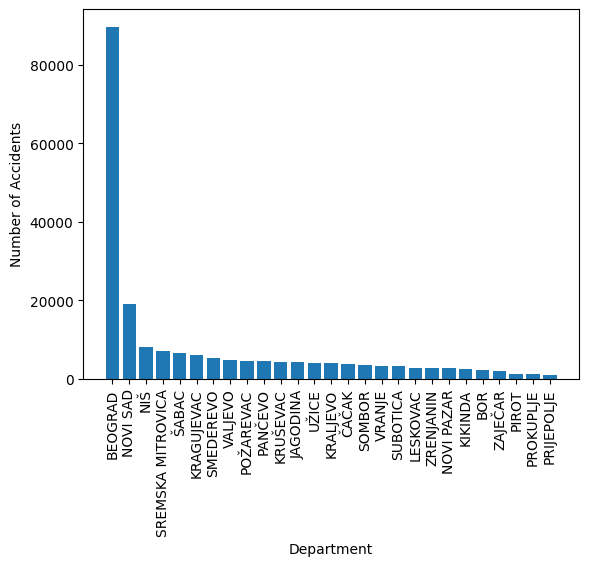

In [35]:
plt.figure()
plt.bar(sorted_by_departpemnt.index, sorted_by_departpemnt.values)
plt.xlabel("Department")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()

In [44]:
sorted_by_municipality = data.groupby('municipality').size().sort_values(ascending=False)
sorted_by_municipality

municipality
NOVI SAD        13251
NOVI BEOGRAD    11806
VOŽDOVAC        10230
PALILULA         9506
ČUKARICA         8283
                ...  
NOVA CRNJA         71
MEDVEĐA            56
TRGOVIŠTE          54
BOSILEGRAD         48
CRNA TRAVA         19
Length: 162, dtype: int64

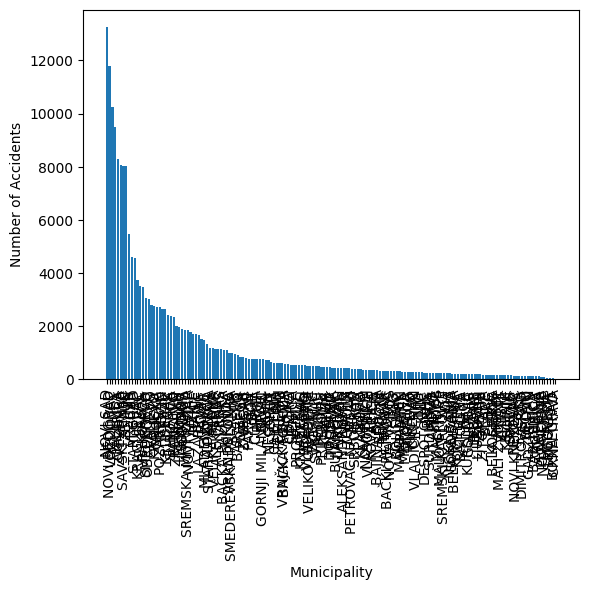

In [45]:
plt.figure()
plt.bar(sorted_by_municipality.index, sorted_by_municipality.values)
plt.xlabel("Municipality")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()

In [46]:
sorted_by_municipality = sorted_by_municipality.iloc[:30]

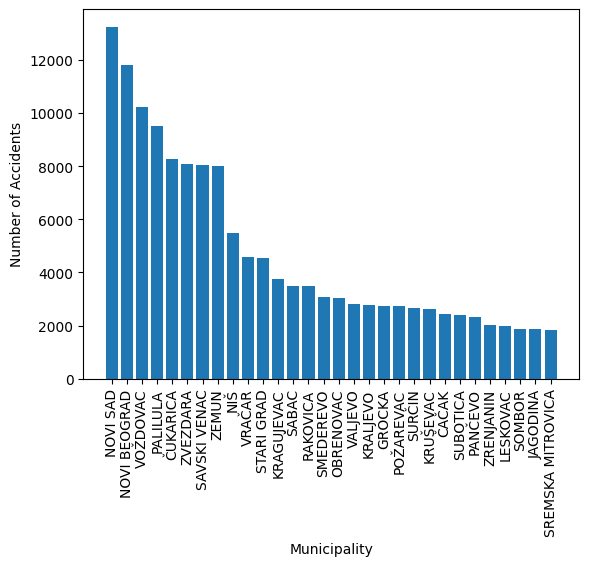

In [47]:
plt.figure()
plt.bar(sorted_by_municipality.index, sorted_by_municipality.values)
plt.xlabel("Municipality")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()

In [50]:
sorted_by_acc_type = data.groupby('accident_type').size().sort_values(ascending=False)
sorted_by_acc_type

accident_type
Sa mat.stetom     121989
Sa povredjenim     79051
Sa poginulim        2925
dtype: int64

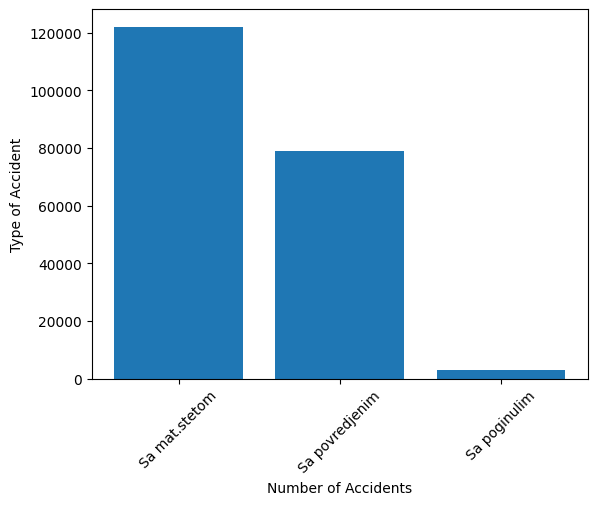

In [52]:
plt.figure()
plt.bar(sorted_by_acc_type.index, sorted_by_acc_type.values)
plt.xlabel("Number of Accidents")
plt.ylabel("Type of Accident")
plt.xticks(rotation=45)
plt.show()

#### Time Analysis

In [57]:
accidents_by_day_of_week = data.groupby('day_of_week').size()
accidents_by_day_of_week

day_of_week
0    30308
1    28585
2    29038
3    29660
4    32456
5    29144
6    24774
dtype: int64

In [70]:
day_of_week = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

days = [day_of_week[d] for d in accidents_by_day_of_week.index]

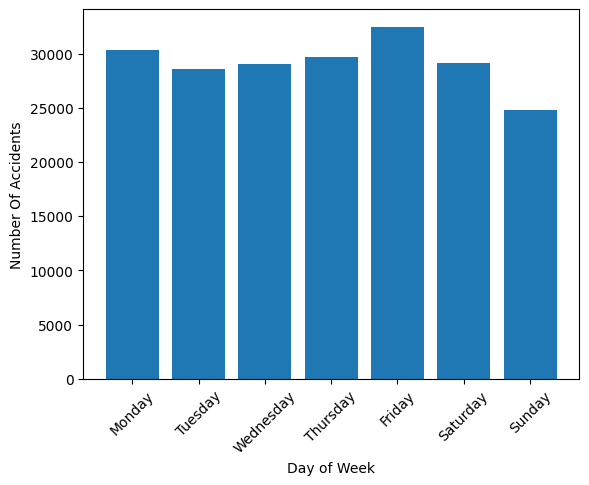

In [73]:
plt.figure()
plt.bar(days, accidents_by_day_of_week.values)
plt.xlabel("Day of Week")
plt.ylabel("Number Of Accidents")
plt.xticks(rotation=45)
plt.show()

In [58]:
accidents_by_month = data.groupby('month').size()
accidents_by_month

month
1     17589
2     15949
3     17550
4     14697
5     16306
6     17071
7     17325
8     16914
9     17525
10    18533
11    16672
12    17834
dtype: int64

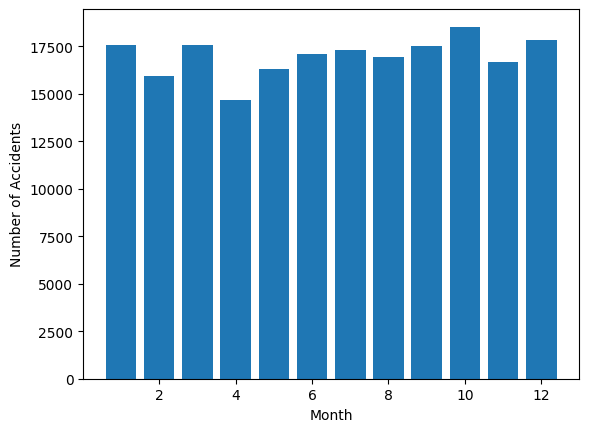

In [62]:
plt.figure()
plt.bar(accidents_by_month.index, accidents_by_month.values)
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

In [64]:
months = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "July",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

month_labels = [months[m] for m in accidents_by_month.index]

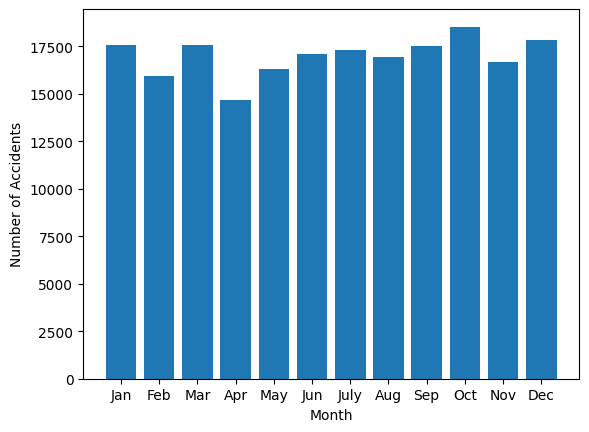

In [65]:
plt.figure()
plt.bar(month_labels, accidents_by_month.values)
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

In [60]:
accidents_by_year = data.groupby('year').size()
accidents_by_year

year
2020    30686
2021    34528
2022    33182
2023    32741
2024    32127
2025    33173
2026     7528
dtype: int64

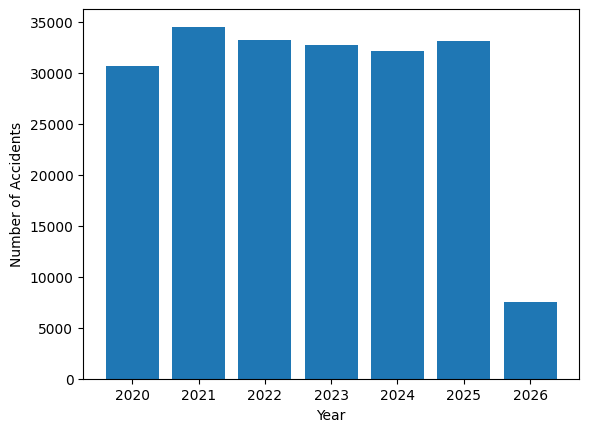

In [61]:
plt.figure()
plt.bar(accidents_by_year.index, accidents_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

#### Correlations